# DecodeLabs — Project 2: Data Classification Using AI
**Iris → Scale → 80/20 Split → KNN (k=5) → Confusion Matrix + F1**

This notebook follows the IPO blueprint from the project deck:

| INPUT | PROCESS | OUTPUT |
|---|---|---|
| Iris domain + feature scaling | Train-test split + KNN | Confusion matrix + F1 score |

*We do not write the rules. We provide history, and the machine derives the logic.*


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, accuracy_score,
)

RANDOM_STATE = 42  # reproducible shuffling/splitting
sns.set_theme(style="whitegrid")

## 1. INPUT — Raw Material: The Iris Benchmark
150 samples · 3 balanced classes (setosa, versicolor, virginica) · 4 features
(sepal length/width, petal length/width).

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print("Feature matrix shape:", X.shape)
print("Class balance:", dict(zip(iris.target_names, np.bincount(y))))
X.head()

Feature matrix shape: (150, 4)
Class balance: {'setosa': 50, 'versicolor': 50, 'virginica': 50}


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# Quick look at the four features grouped by species
X.assign(species=pd.Categorical.from_codes(y, iris.target_names)).describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. The Gatekeeper Rule — Feature Scaling
KNN measures distance, so features on larger numeric ranges would dominate.
`StandardScaler` rescales every feature to **mean = 0, variance = 1** so each
contributes fairly.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Confirm: means ~0, std ~1
print("Means after scaling:", np.round(X_scaled.mean(axis=0), 4))
print("Stds  after scaling:", np.round(X_scaled.std(axis=0), 4))

Means after scaling: [-0. -0. -0. -0.]
Stds  after scaling: [1. 1. 1. 1.]


## 3. Structural Integrity — The Split
Shuffle, then carve off **80% training / 20% testing**. `stratify=y` keeps the
3 classes balanced in both sets; the test set stays locked away for validation.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,      # preserve class balance
    shuffle=True,    # remove order bias
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 120
Testing samples : 30


## 4. PROCESS — The Algorithm: K-Nearest Neighbors (k = 5)
The proximity principle: a new point is labelled by the **majority vote** of its
5 closest neighbors. Three lines: *instantiate → fit → predict*.

In [6]:
model = KNeighborsClassifier(n_neighbors=5)  # INSTANTIATE — build the frame
model.fit(X_train, y_train)                  # FIT — memorize the map
predictions = model.predict(X_test)          # PREDICT — apply the logic

predictions[:10]

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1])

## 5. OUTPUT VALIDATION
*In imbalanced data, accuracy is a lie — we look deeper.* Here the data is
balanced, but we still report the **confusion matrix**, **per-class
precision/recall**, and the **F1 score** (the harmonic mean of precision &
recall).

In [7]:
acc = accuracy_score(y_test, predictions)
f1_macro = f1_score(y_test, predictions, average="macro")

print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {f1_macro:.4f}\n")
print(classification_report(y_test, predictions, target_names=iris.target_names))

Accuracy : 0.9333
Macro F1 : 0.9327

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



### The Diagnostic Tool — Confusion Matrix
Diagonal = correct predictions. Off-diagonal cells are the errors
(false alarms / missed detections).

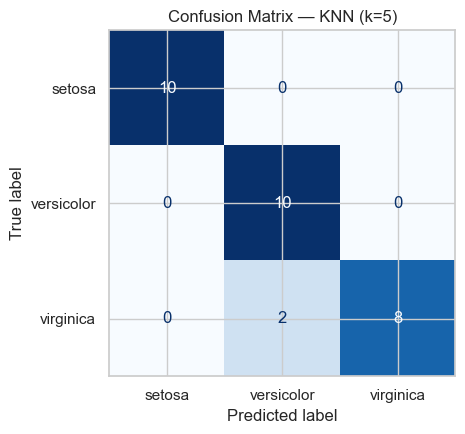

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  2,  8]], dtype=int64)

In [8]:
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Confusion Matrix — KNN (k=5)")
plt.tight_layout()
plt.show()
cm

## 6. BONUS — Tuning the Engine: Choosing "K"
Too small a K overfits to noise; too large underfits. To choose K reliably we use
**5-fold cross-validation** on the training data rather than a single split — the
30-sample test set is too small to trust on its own. We average the error across
folds for each K and look for **the elbow**, where error bottoms out before
rising again.

K with lowest cross-validated error: 6


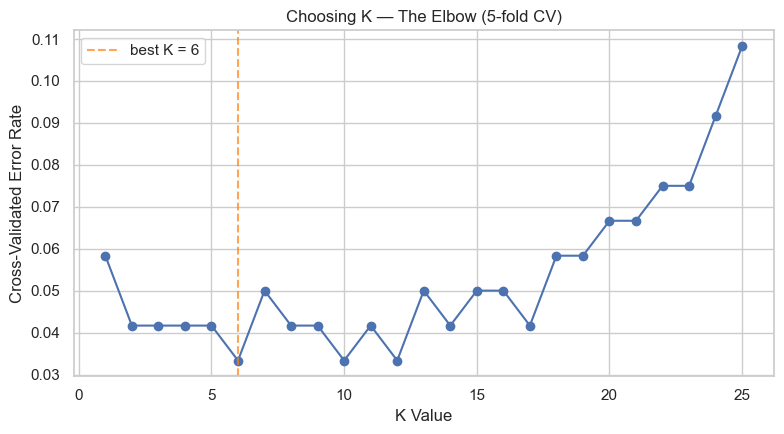

In [9]:
from sklearn.model_selection import cross_val_score

ks = range(1, 26)
cv_errors = []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k)
    # 5-fold CV accuracy on the TRAINING set, then convert to error
    scores = cross_val_score(m, X_train, y_train, cv=5, scoring="accuracy")
    cv_errors.append(1 - scores.mean())

best_k = list(ks)[int(np.argmin(cv_errors))]
print("K with lowest cross-validated error:", best_k)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(ks), cv_errors, marker="o")
ax.axvline(best_k, color="tab:orange", linestyle="--", alpha=0.7,
           label=f"best K = {best_k}")
ax.set_xlabel("K Value")
ax.set_ylabel("Cross-Validated Error Rate")
ax.set_title("Choosing K — The Elbow (5-fold CV)")
ax.legend()
plt.tight_layout()
plt.show()

## Recap
- Loaded the balanced 150-sample Iris dataset (4 features, 3 classes).
- Scaled features so distance-based KNN treats them fairly.
- Split 80/20 with stratification to protect class balance.
- Trained `KNeighborsClassifier(n_neighbors=5)` and validated on held-out data.
- Reported accuracy, the confusion matrix, and the F1 score; swept K for the elbow.

*Tip: treat a low score as a learning opportunity — try a different K, swap in
another algorithm, or test the model on brand-new measurements.*
